# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure


| Field | Your answer                                                                                                                                                                                                                                                                          |
|-------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool | OpenCode Zen + Big Pickle                                                                                                                                                                                                                                                            |
| Used for | Explaining the assignment tasks and Moodle fields; reviewing the training code and its results; adding a fixed random seed (keras.utils.set_random_seed(42)) for reproducible runs; adding explanatory comments to the code cells; and moving dropout so one layer follows each hidden layer.                                                                                                    |
| Verified how | Every suggestion was reviewed and accepted manually. The notebook was re-run end-to-end after each change, and reproducibility was confirmed by executing it twice with identical outputs (same test accuracy and worst-confused pair). Results were checked against the assignment requirements.<br/> |
| Not used for | Designing the neural network architecture from scratch, writing the original MNIST training code, or producing the final submission without my own understanding and review.                                                                                                                         |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

In [2]:
# Fix all random seeds so every run gives identical results.
# This single call seeds the RNG for Python, NumPy and TensorFlow,
# covering weight initialization, batch shuffling and dropout masks.
keras.utils.set_random_seed(42)

## 1. Load MNIST

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1] and convert to float32
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten each 28x28 image into a 784-dimensional vector (dense layers need 1D input)
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10  # digits 0-9
print(x_train_flat.shape, y_train.shape)

(60000, 784) (60000,)


## 2. Validation split

In [4]:
val_samples = 10000

# Hold out the first 10,000 training images as the validation set
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]

# Keep the remaining 50,000 images for training
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [5]:
def build_model(use_dropout=False, dropout_rate=0.3):
    # Input: a flattened 784-pixel image
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
    ])
    # Dropout after the first hidden layer
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(256, activation="relu"))
    # Dropout after the second hidden layer as well
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    # Output layer: 10 neurons with softmax -> probabilities over digits 0-9
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",  # accepts integer labels directly
        metrics=["accuracy"],
    )
    return model


## 4. Train baseline (no dropout)

In [6]:
EPOCHS = 20
BATCH_SIZE = 128

# Train the baseline model (no dropout)
model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Evaluate the final model on the held-out test set
test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9271 - loss: 0.2539 - val_accuracy: 0.9647 - val_loss: 0.1241
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9716 - loss: 0.0928 - val_accuracy: 0.9703 - val_loss: 0.0970
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9830 - loss: 0.0568 - val_accuracy: 0.9749 - val_loss: 0.0859
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0359 - val_accuracy: 0.9782 - val_loss: 0.0812
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0249 - val_accuracy: 0.9758 - val_loss: 0.0931
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9754 - val_loss: 0.0913
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9714 - val_loss: 0.1176
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9931 - loss: 0.0186 - val_accuracy: 0.

## 5. Train with dropout

In [7]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
# Train the same architecture but with dropout enabled
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Evaluate the dropout model on the held-out test set
_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9027 - loss: 0.3204 - val_accuracy: 0.9595 - val_loss: 0.1326
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9581 - loss: 0.1343 - val_accuracy: 0.9699 - val_loss: 0.0983
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9704 - loss: 0.0971 - val_accuracy: 0.9777 - val_loss: 0.0751
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9751 - loss: 0.0762 - val_accuracy: 0.9781 - val_loss: 0.0720
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9807 - loss: 0.0614 - val_accuracy: 0.9783 - val_loss: 0.0735
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0534 - val_accuracy: 0.9786 - val_loss: 0.0738
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0490 - val_accuracy: 0.9814 - val_loss: 0.0682
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0406 - val_accuracy: 0.

## 6. Compare learning curves

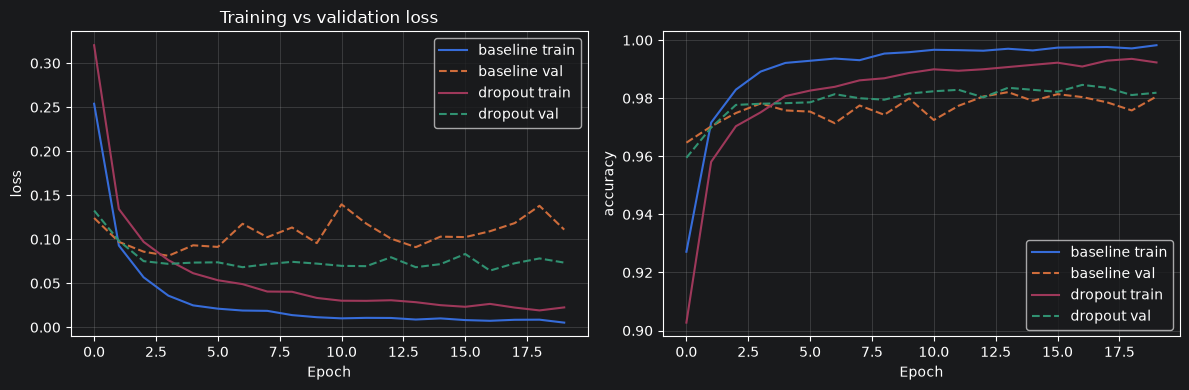

In [8]:
def plot_histories(histories, labels, metric="loss"):
    # Left panel: training vs validation loss
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # Right panel: training vs validation accuracy
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

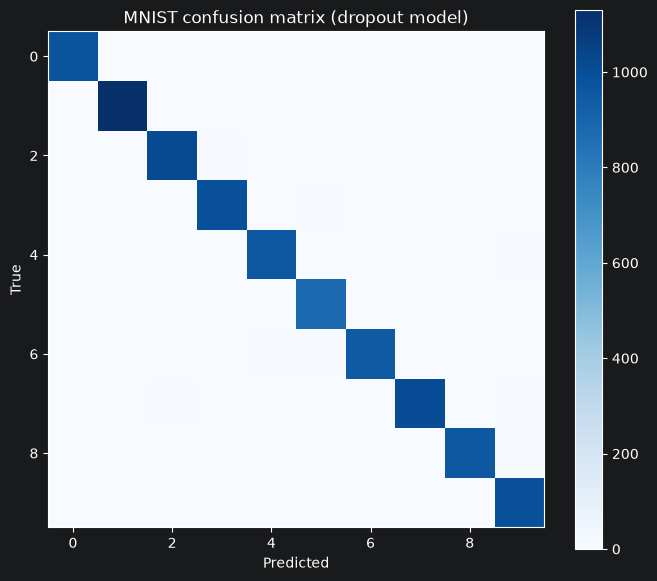

Worst confused pair (Moodle a2_worst_pair): 4-9 (11 errors)


In [9]:
y_pred = np.argmax(model_dropout.predict(x_test_flat, verbose=0), axis=1)
#argmax find the position of largest number -- the largest probability for every row(axis=1)--predicted number
cm = confusion_matrix(y_test, y_pred)
#ex: cm = np.array([
   # [8, 2, 0],
   # [1, 6, 3],
   # [0, 2, 9]])
#row is true label(0,1,2), column is predicted label, diagonal is correct, off-diagonal is false.

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0) #clear the counts for correct prediction in diagonal
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape) #find the max number and reshape to two-dimension coordination
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")
#the worst pair is the largest off-diagonal entry

## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output

1. Integer labels are represented as single numbers, such as 0, 1, 2, ..., 9. One-hot labels are arrays such as [0,0,1], [1,0,0], or [0,1,0]. The length of the array equals the number of classes. The correct class is represented by 1, and all other positions are 0.
2. The loss compares the predicted probability distribution with the true integer label and penalizes the model when it assigns a low probability to the correct class.
3. Softmax converts the model's outputs into probabilities that sum to 1 across all classes. Sparse categorical crossentropy uses these probabilities to measure how well the model predicts the correct class, so they are commonly used together. This is suitable for single-label multi-class classification, where each image belongs to exactly one of the 10 classes.
